In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#ler o arquivo csv
df_exames = pd.read_csv('./datasets/exames_diabete.csv')
#df_exames.info()
df_exames.head(10)

,id_paciente,genero,idade,peso,altura,resultado
0,1,M,46,83,165,98
1,2,F,23,83,164,82
2,3,M,39,71,154,93
3,4,F,26,103,165,95
4,5,M,27,55,176,100
5,6,M,64,93,190,117
6,7,F,21,70,182,90
7,8,F,60,101,179,84
8,9,F,63,83,189,92
9,10,F,65,78,175,121


In [5]:
df_exames.drop(columns=['id_paciente'], inplace=True)
df_exames.head(10)

,genero,idade,peso,altura,resultado
0,M,46,83,165,98
1,F,23,83,164,82
2,M,39,71,154,93
3,F,26,103,165,95
4,M,27,55,176,100
5,M,64,93,190,117
6,F,21,70,182,90
7,F,60,101,179,84
8,F,63,83,189,92
9,F,65,78,175,121


In [6]:
#one-hot encoding - vai transformar a coluna de sexo em 0 e 1, onde 0 é feminino e 1 é masculino - uma variavel categórica em binaria
#df_exames = pd.get_dummies(df_exames, columns=['genero']) #desse jeito as veriaveis serão booleanas
df_exames = pd.get_dummies(df_exames, columns=['genero'], dtype='int64')
df_exames.head(10)

,idade,peso,altura,resultado,genero_F,genero_M
0,46,83,165,98,0,1
1,23,83,164,82,1,0
2,39,71,154,93,0,1
3,26,103,165,95,1,0
4,27,55,176,100,0,1
5,64,93,190,117,0,1
6,21,70,182,90,1,0
7,60,101,179,84,1,0
8,63,83,189,92,1,0
9,65,78,175,121,1,0


<Axes: >

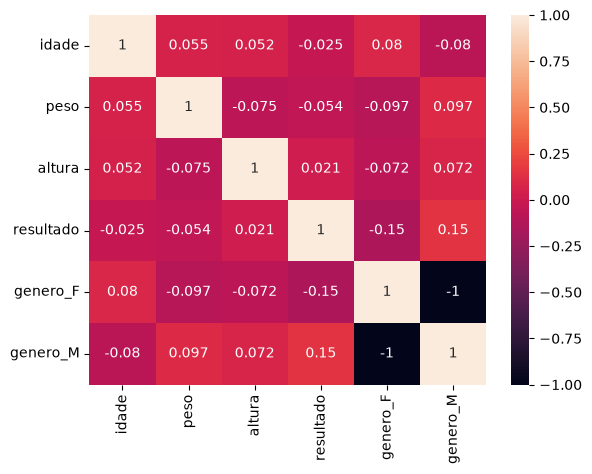

In [7]:
# apresentar mapa de calor com a correlação entre as variáveis
sns.heatmap(df_exames.corr(),vmin=-1, vmax=1, annot=True)

<Axes: >

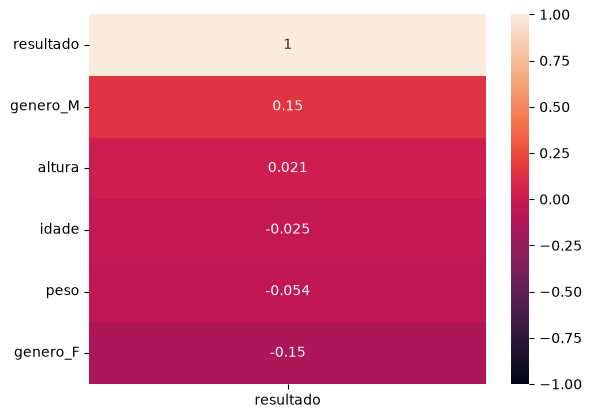

In [8]:
#mapa de correlação só com a varievel target (resultado)
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1, annot=True)

array([[<Axes: xlabel='idade', ylabel='idade'>,
        <Axes: xlabel='peso', ylabel='idade'>,
        <Axes: xlabel='altura', ylabel='idade'>,
        <Axes: xlabel='resultado', ylabel='idade'>,
        <Axes: xlabel='genero_F', ylabel='idade'>,
        <Axes: xlabel='genero_M', ylabel='idade'>],
       [<Axes: xlabel='idade', ylabel='peso'>,
        <Axes: xlabel='peso', ylabel='peso'>,
        <Axes: xlabel='altura', ylabel='peso'>,
        <Axes: xlabel='resultado', ylabel='peso'>,
        <Axes: xlabel='genero_F', ylabel='peso'>,
        <Axes: xlabel='genero_M', ylabel='peso'>],
       [<Axes: xlabel='idade', ylabel='altura'>,
        <Axes: xlabel='peso', ylabel='altura'>,
        <Axes: xlabel='altura', ylabel='altura'>,
        <Axes: xlabel='resultado', ylabel='altura'>,
        <Axes: xlabel='genero_F', ylabel='altura'>,
        <Axes: xlabel='genero_M', ylabel='altura'>],
       [<Axes: xlabel='idade', ylabel='resultado'>,
        <Axes: xlabel='peso', ylabel='resultado'>,


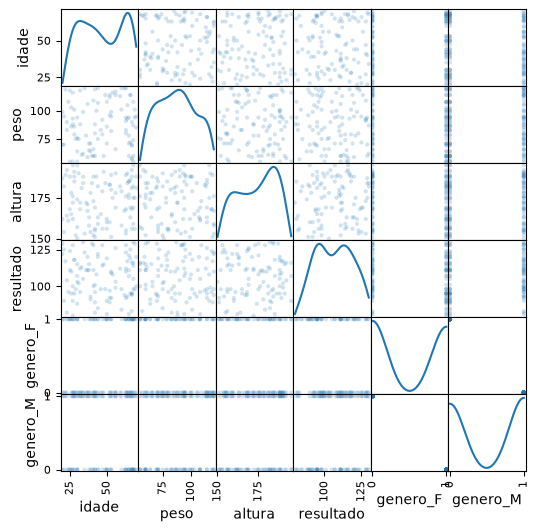

In [9]:
# box scatter plot com distruibuição 
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(6,6), diagonal='kde')

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>,
        <Axes: title={'center': 'resultado'}>],
       [<Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>, <Axes: >, <Axes: >]],
      dtype=object)

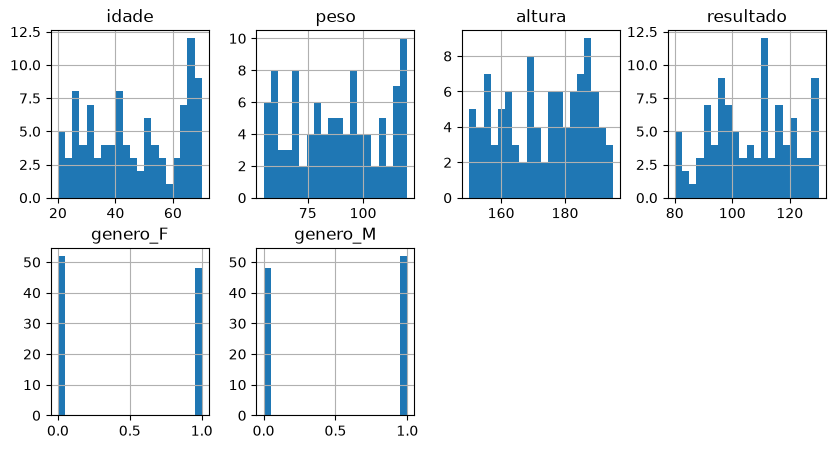

In [10]:
#histograma de todas as variáveis
df_exames.hist(layout=(2,4), figsize=(10,5), bins=20)

In [11]:
#feature
#IMC
# IMC = peso / (altura^2)
df_exames['imc'] = df_exames['peso'] / ((df_exames['altura']/100) ** 2)
df_exames.head(10)

,idade,peso,altura,resultado,genero_F,genero_M,imc
0,46,83,165,98,0,1,30.486685
1,23,83,164,82,1,0,30.859607
2,39,71,154,93,0,1,29.937595
3,26,103,165,95,1,0,37.832874
4,27,55,176,100,0,1,17.755682
5,64,93,190,117,0,1,25.761773
6,21,70,182,90,1,0,21.132713
7,60,101,179,84,1,0,31.522112
8,63,83,189,92,1,0,23.235632
9,65,78,175,121,1,0,25.469388


### Segunda parte do código - Entrando na parte de Machine Learning

In [45]:
#importando bibliotecas para machine learning - sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


### Modelo 1 - Sem IMC
### convertendo o dataframe em variáveis de entrada (X) - independente e saída (y) - resposta 

In [ ]:

X = df_exames.drop(columns=['resultado','imc'])
y = df_exames['resultado']


In [14]:
#dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [15]:
# treinar o modelo de regressão linear sklearn modelo 1
model1 = LinearRegression().fit(X_train, y_train)

In [20]:
# fazer predições com o modelo teste
y_pred = model1.predict(X_test)
model1.coef_


array([-0.00694816, -0.0788198 ,  0.10991808, -2.96913112,  2.96913112])

In [21]:
model1.intercept_

np.float64(94.21133142019875)

In [22]:
# R2 score - coeficiente de determinação - de -inf ate 1 de quando x explicam a variavel y, quanto mais próximo de 1 melhor
model1.score(X_test, y_test)

-0.1364090447910642

In [ ]:
r2_score(y_test, y_pred) #igual ao model1.score(X_test, y_test)

-0.1364090447910642

In [23]:
model1.score(X_train, y_train)

0.06218388634297267

In [30]:
# MAE - Mean Absolute Error - erro absoluto médio - quanto menor melhor
mean_absolute_error(y_test, y_pred)

12.695569181179541

### Modelo 2
### Regressão linear Simples - apenas IMC 

In [31]:
 
X = pd.DataFrame(df_exames['imc'])
y = df_exames['resultado']


In [32]:
#dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [33]:
#treinar o modelo de regressão linear sklearn modelo 2
model2 = LinearRegression().fit(X_train, y_train)

In [35]:
#gerar predições com o modelo teste
y_pred = model2.predict(X_test)
model2.coef_

array([-0.21677589])

In [36]:
model2.intercept_

np.float64(112.15019229088836)

In [38]:
#R2 score - coeficiente de determinação - de -inf ate 1 de quando x explicam a variavel y, quanto mais próximo de 1 melhor - conjuno de treinamento
model2.score(X_train, y_train)

0.015285962664806862

In [39]:
model2.score(X_test, y_test)

-0.0889832856240178

In [46]:
# Mae - Mean Absolute Error - erro absoluto médio - quanto menor melhor
mean_absolute_error(y_test, y_pred)

12.505651407060103

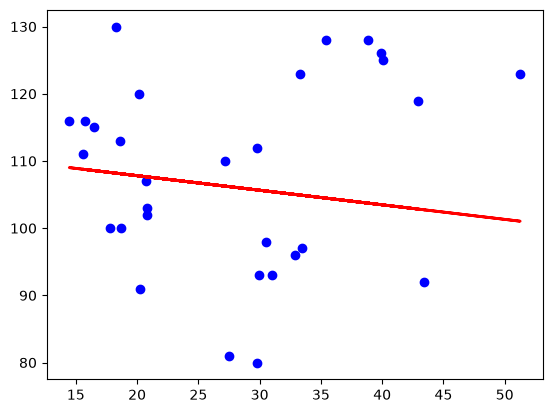

In [48]:
#mostrar como a reta foi calculada com o modelo 2 - IMC
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red', linewidth=2)